In [144]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.inspection import permutation_importance
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, brier_score_loss
import geopandas as gpd
from shapely.geometry import Point, Polygon
import geodatasets
import seaborn as sns
import statsmodels.api as sm
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import RepeatedKFold
from xgboost import XGBRegressor, XGBClassifier
from sklearn.isotonic import IsotonicRegression
from sklearn.tree import DecisionTreeClassifier, export_text




RANDOM_STATE = 42
TARGET = "delay_probability"
TIME_COL = "timestamp"


In [123]:
pip install xgboost


  Using cached xgboost-3.0.5-py3-none-macosx_12_0_arm64.whl.metadata (2.1 kB)
Using cached xgboost-3.0.5-py3-none-macosx_12_0_arm64.whl (2.0 MB)
Note: you may need to restart the kernel to use updated packages.


In [5]:
df = pd.read_csv("dynamic_supply_chain_logistics_dataset.csv")
df


,timestamp,vehicle_gps_latitude,vehicle_gps_longitude,fuel_consumption_rate,eta_variation_hours,traffic_congestion_level,warehouse_inventory_level,loading_unloading_time,handling_equipment_availability,order_fulfillment_status,weather_condition_severity,port_congestion_level,shipping_costs,supplier_reliability_score,lead_time_days,historical_demand,iot_temperature,cargo_condition_status,route_risk_level,customs_clearance_time,driver_behavior_score,fatigue_monitoring_score,disruption_likelihood_score,delay_probability,risk_classification,delivery_time_deviation
0,2021-01-01 00:00:00,40.375568,-77.014318,5.136512,4.998009,5.927586,985.716862,4.951392,0.481294,0.761166,0.359066,4.289160,456.503853,0.986064,2.128009,100.772854,0.574400,0.777263,1.182116,0.502006,0.033843,0.978599,0.506152,0.885291,Moderate Risk,9.110682
1,2021-01-01 01:00:00,33.507818,-117.036902,5.101512,0.984929,1.591992,396.700206,1.030379,0.620780,0.196594,0.230660,7.018373,640.408205,0.463233,12.608166,5313.738114,-9.753493,0.091839,9.611988,0.966774,0.201725,0.918586,0.980784,0.544178,High Risk,8.175281
2,2021-01-01 02:00:00,30.020640,-75.269224,5.090803,4.972665,8.787765,832.408935,4.220229,0.810933,0.152742,0.027210,9.605064,155.749314,0.598561,14.124452,1595.049146,-6.491034,0.253529,6.570431,0.945627,0.264045,0.394215,0.998633,0.803322,High Risk,1.283594
3,2021-01-01 03:00:00,36.649223,-70.190529,8.219558,3.095064,0.045257,0.573283,0.530186,0.008525,0.811885,0.616619,8.899616,104.317961,0.742735,3.818972,2530.431941,-0.151276,0.877576,0.548952,4.674035,0.362885,0.905444,0.993320,0.025977,High Risk,9.304897
4,2021-01-01 04:00:00,30.001279,-70.012195,5.000075,3.216077,8.004851,914.925067,3.620890,0.020083,0.053659,0.952385,0.061760,977.222528,0.431088,14.001491,2146.190197,2.429448,0.262081,8.861443,3.445429,0.016957,0.258702,0.912433,0.991122,High Risk,7.752484
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32060,2024-08-28 20:00:00,48.496665,-104.031158,5.421806,4.394370,0.192421,127.684977,3.607803,0.208643,0.992997,0.792648,9.700832,413.261158,0.316930,1.094685,205.682808,-8.835069,0.199377,9.893402,0.966050,0.109571,0.511074,0.953467,0.916745,High Risk,5.506049
32061,2024-08-28 21:00:00,34.670137,-89.893091,10.624778,2.700635,8.736143,84.638889,1.218165,0.472389,0.946031,0.034156,2.752909,243.311145,0.221629,8.320477,1111.961023,-2.517654,0.673775,0.854378,1.665889,0.530289,0.868418,0.995329,0.808963,High Risk,-1.876938
32062,2024-08-28 22:00:00,42.963338,-82.149873,5.071596,0.485288,7.420200,48.500920,4.999149,0.064366,0.437687,0.022338,0.498235,722.121687,0.348949,1.212227,600.132813,29.410878,0.949644,4.480552,0.690990,0.537100,0.896798,0.442299,0.959197,Moderate Risk,9.790219
32063,2024-08-28 23:00:00,32.082410,-70.070154,5.000000,4.759411,0.932050,972.437425,0.505242,0.250949,0.517051,0.782338,9.697467,484.498261,0.185130,6.129439,1354.437588,-6.951137,0.407377,9.185549,4.462204,0.012896,0.463018,0.999999,0.557340,High Risk,9.956879


In [6]:
df["timestamp"] = pd.to_datetime(df["timestamp"], errors="coerce")
df = df.sort_values("timestamp").set_index("timestamp")

In [7]:
df.shape

(32065, 25)

In [8]:
# Data types and missing values
df.info()

# Statistical summary (numerical columns)
df.describe()


<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 32065 entries, 2021-01-01 00:00:00 to 2024-08-29 00:00:00
Data columns (total 25 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   vehicle_gps_latitude             32065 non-null  float64
 1   vehicle_gps_longitude            32065 non-null  float64
 2   fuel_consumption_rate            32065 non-null  float64
 3   eta_variation_hours              32065 non-null  float64
 4   traffic_congestion_level         32065 non-null  float64
 5   warehouse_inventory_level        32065 non-null  float64
 6   loading_unloading_time           32065 non-null  float64
 7   handling_equipment_availability  32065 non-null  float64
 8   order_fulfillment_status         32065 non-null  float64
 9   weather_condition_severity       32065 non-null  float64
 10  port_congestion_level            32065 non-null  float64
 11  shipping_costs                   32065 non-nu

,vehicle_gps_latitude,vehicle_gps_longitude,fuel_consumption_rate,eta_variation_hours,traffic_congestion_level,warehouse_inventory_level,loading_unloading_time,handling_equipment_availability,order_fulfillment_status,weather_condition_severity,port_congestion_level,shipping_costs,supplier_reliability_score,lead_time_days,historical_demand,iot_temperature,cargo_condition_status,route_risk_level,customs_clearance_time,driver_behavior_score,fatigue_monitoring_score,disruption_likelihood_score,delay_probability,delivery_time_deviation
count,32065.000000,32065.000000,32065.000000,32065.000000,3.206500e+04,3.206500e+04,32065.000000,3.206500e+04,32065.000000,3.206500e+04,32065.000000,32065.000000,3.206500e+04,32065.000000,32065.000000,32065.000000,3.206500e+04,32065.000000,32065.000000,3.206500e+04,3.206500e+04,32065.000000,32065.000000,32065.000000
mean,38.023589,-90.116648,8.011735,2.893068,4.991493e+00,2.992547e+02,2.291669,3.026954e-01,0.600740,4.976082e-01,6.978414,459.374452,5.008499e-01,5.227502,6022.001286,0.044792,2.972816e-01,7.001144,2.296448,4.983913e-01,6.008723e-01,0.803656,0.699077,5.177648
std,6.917909,17.369244,4.264960,2.274044,3.532048e+00,3.234435e+02,1.554202,3.259146e-01,0.345672,3.532853e-01,3.251051,312.183487,3.535281e-01,4.523085,3427.638017,14.187486,3.216115e-01,3.236328,1.555932,3.541589e-01,3.458101e-01,0.279185,0.324514,4.157988
min,30.000000,-119.999998,5.000000,-1.999993,1.091633e-09,1.322210e-12,0.500000,4.565769e-16,0.000001,4.536949e-09,0.000002,100.000000,6.904319e-10,1.000000,100.002966,-10.000000,7.255415e-19,0.000050,0.500000,4.043927e-09,3.269508e-07,0.000048,0.000003,-1.999998
25%,31.280550,-106.253913,5.019984,1.185744,1.474720e+00,1.605163e+01,0.774798,1.710828e-02,0.277096,1.440135e-01,4.513889,154.017124,1.453158e-01,1.237490,2822.607616,-9.931074,1.678269e-02,4.593407,0.776166,1.443567e-01,2.783148e-01,0.693739,0.456009,1.269197
50%,36.413820,-86.293414,5.636036,3.882059,4.981244e+00,1.572880e+02,1.917121,1.595151e-01,0.680553,4.961781e-01,8.383225,388.996911,5.032655e-01,3.297654,6785.123209,-7.858681,1.549760e-01,8.385605,1.938273,4.988468e-01,6.831130e-01,0.958128,0.839599,6.113662
75%,44.453655,-73.079367,9.669944,4.884355,8.534902e+00,5.405980e+02,3.734188,5.535954e-01,0.938160,8.498226e-01,9.838150,753.007203,8.539780e-01,8.625720,9374.252913,6.024012,5.405408e-01,9.836152,3.750817,8.510762e-01,9.372889e-01,0.998746,0.982391,9.249206
max,50.000000,-70.000000,19.999875,5.000000,9.999999e+00,9.999993e+02,5.000000,9.999995e-01,1.000000,1.000000e+00,10.000000,999.999853,1.000000e+00,14.999995,10000.000000,39.999886,1.000000e+00,10.000000,5.000000,1.000000e+00,1.000000e+00,1.000000,1.000000,10.000000


In [10]:
# List of binary columns to fix
binary_cols = [
    "handling_equipment_availability",
    "order_fulfillment_status",
    "cargo_condition_status"
]

# Apply threshold 0.5 → cast to int (0/1)
for col in binary_cols:
    if col in df.columns:
        df[col] = (df[col] > 0.5).astype(int)

# Quick check: show unique values per column
for col in binary_cols:
    if col in df.columns:
        print(col, "unique values:", df[col].unique())


handling_equipment_availability unique values: [0 1]
order_fulfillment_status unique values: [1 0]
cargo_condition_status unique values: [1 0]


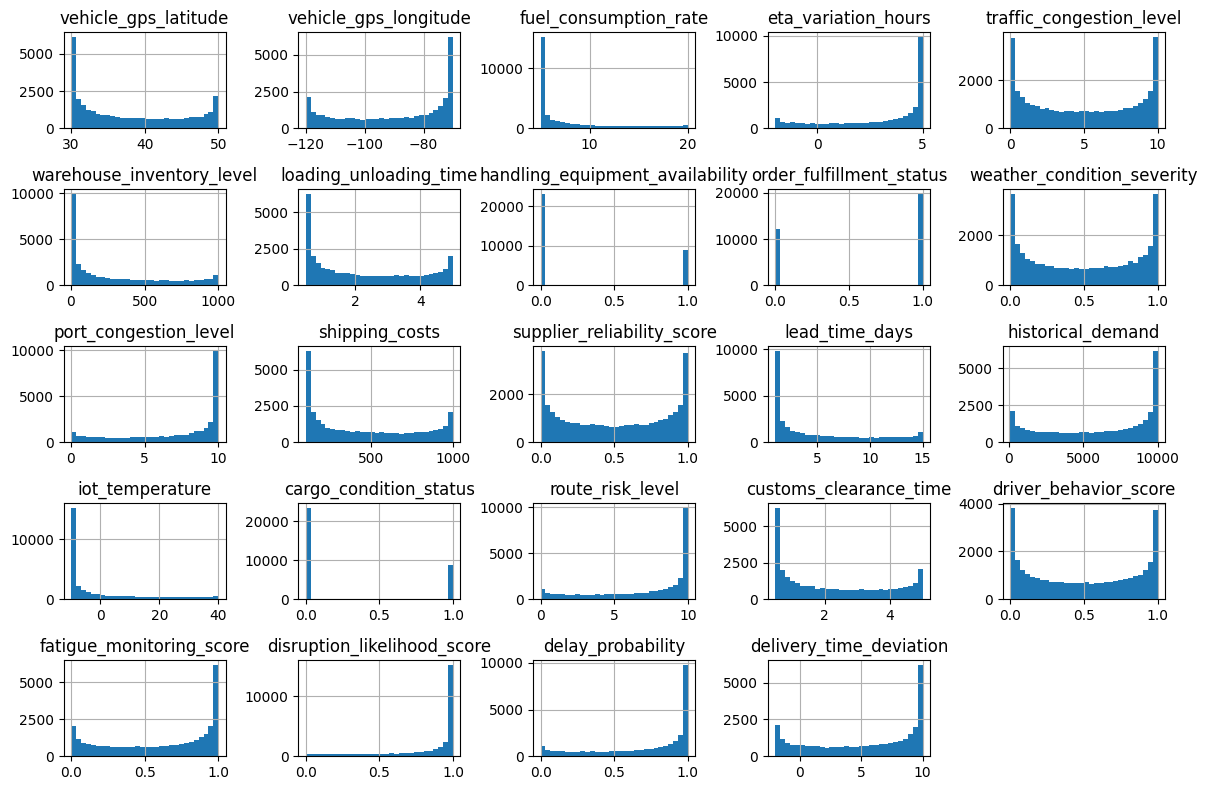

In [11]:
numeric_cols = df.select_dtypes(include="number").columns

# Plot distribution of first 6 numeric columns
df[numeric_cols[:]].hist(bins=30, figsize=(12,8))
plt.tight_layout()
plt.show()

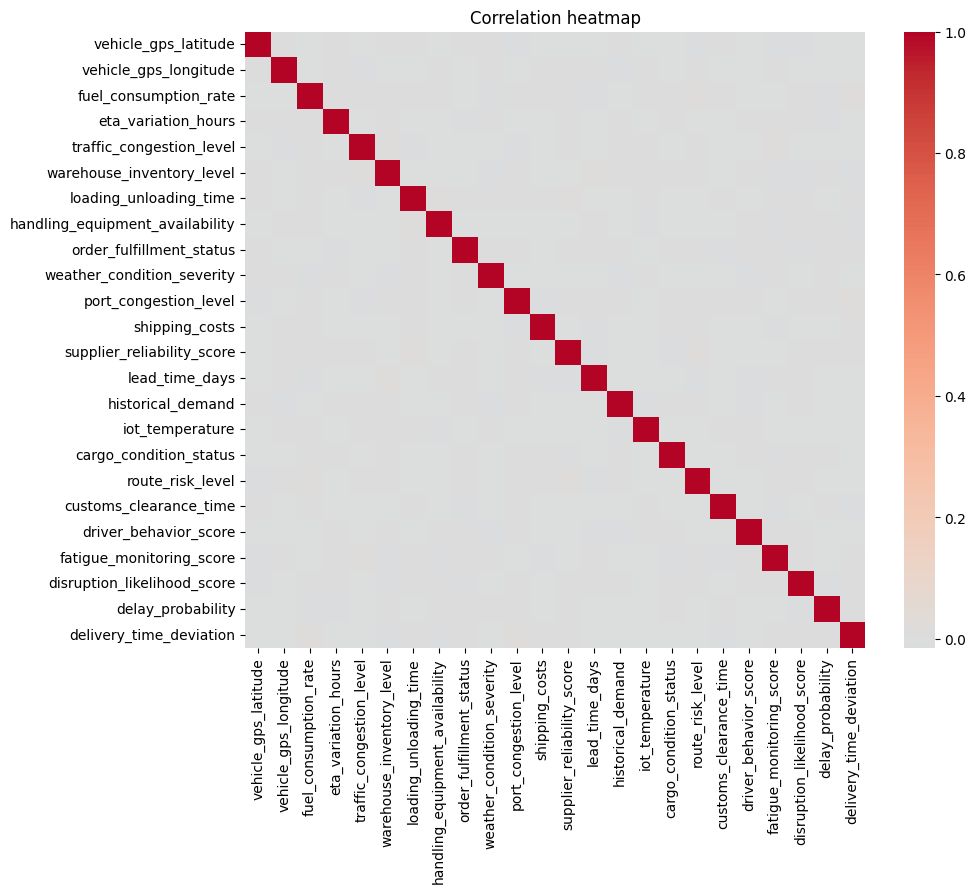

In [ ]:
plt.figure(figsize=(10,8))
sns.heatmap(df[numeric_cols].corr(), cmap="coolwarm", center=0)
plt.title("Correlation heatmap")
plt.show()

In [17]:
df = df.reset_index()
daily = df.resample("D", on="timestamp").mean(numeric_only=True)

kpis = [
    "traffic_congestion_level", "port_congestion_level",
    "weather_condition_severity", "delay_probability",
    "delivery_time_deviation"
]
kpis = [c for c in kpis if c in daily.columns]
# Make sure timestamp is parsed as datetime
df["timestamp"] = pd.to_datetime(df["timestamp"], errors="coerce")

# Set it as index
df = df.set_index("timestamp")

# Now resample by day
daily = df.resample("D").mean(numeric_only=True)

(daily.head())


,vehicle_gps_latitude,vehicle_gps_longitude,fuel_consumption_rate,eta_variation_hours,traffic_congestion_level,warehouse_inventory_level,loading_unloading_time,handling_equipment_availability,order_fulfillment_status,weather_condition_severity,port_congestion_level,shipping_costs,supplier_reliability_score,lead_time_days,historical_demand,iot_temperature,cargo_condition_status,route_risk_level,customs_clearance_time,driver_behavior_score,fatigue_monitoring_score,disruption_likelihood_score,delay_probability,delivery_time_deviation
timestamp,,,,,,,,,,,,,,,,,,,,,,,,
2021-01-01,36.851297,-86.656795,6.658842,3.046360,5.297886,301.576803,2.540595,0.166667,0.625000,0.485589,6.050232,400.038948,0.513834,5.779030,6087.738444,3.661447,0.250000,6.777202,2.235946,0.404497,0.742520,0.855860,0.659014,5.629205
2021-01-02,37.939861,-81.869941,7.252002,2.913967,4.753500,371.421763,2.321280,0.208333,0.625000,0.488634,5.507313,565.635388,0.449355,5.994782,7514.016379,3.200548,0.250000,7.373138,1.880268,0.456961,0.555704,0.919868,0.738776,5.897185
2021-01-03,38.971873,-90.916963,7.489807,2.957139,5.374531,255.950387,2.642499,0.250000,0.666667,0.494853,6.993451,487.533988,0.462318,5.020295,6291.804184,-2.203399,0.333333,6.605774,1.840277,0.384853,0.600787,0.852160,0.727337,5.165200
2021-01-04,39.040123,-88.739211,7.578624,2.490429,5.349757,341.890747,2.551933,0.208333,0.583333,0.527365,6.206441,343.179154,0.656553,3.699846,5355.534489,-1.077952,0.166667,6.346819,2.496738,0.535537,0.569891,0.730925,0.731175,5.478182
2021-01-05,39.503442,-91.387185,7.619207,2.836737,5.024538,288.292171,1.902655,0.333333,0.708333,0.501393,7.805846,382.974045,0.399389,5.169301,6492.383313,-1.618375,0.375000,6.959716,2.336704,0.487145,0.601832,0.788526,0.568279,4.698579


In [ ]:
(df["risk_classification"].value_counts(normalize=True)
    .rename("share")
    .mul(100)
    .round(1))


risk_classification
High Risk        74.7
Moderate Risk    15.6
Low Risk          9.7
Name: share, dtype: float64

Filtered size: 300


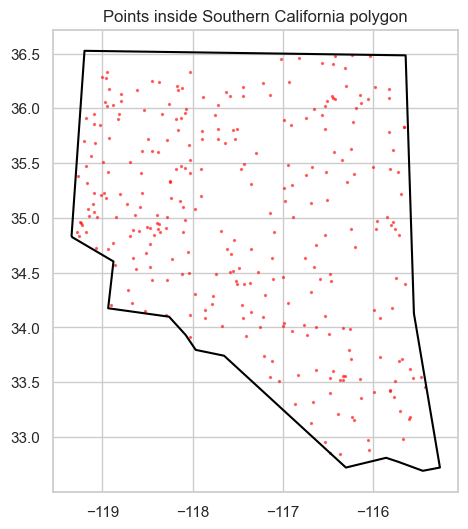

In [60]:
import geopandas as gpd
from shapely.geometry import Point, Polygon

# Your columns
lat_col = "vehicle_gps_latitude"
lon_col = "vehicle_gps_longitude"

# Southern California polygon vertices (lat, lon pairs)
coords = [
    (32.7219, -116.3004),
    (33.7424, -117.6512),
    (33.7958, -117.966),
    (33.9322, -118.0775),
    (34.0984, -118.2611),
    (34.1755, -118.9365),
    (34.6027, -118.8775),
    (34.8281, -119.343),
    (36.525,  -119.1988),
    (36.4835, -115.6381),
    (34.128,  -115.5463),
    (32.7219, -115.2578),
    (32.6922, -115.448),
    (32.7753, -115.7234),
    (32.8109, -115.8545)
]

# Build polygon (lon, lat order for shapely)
poly = Polygon([(lon, lat) for lat, lon in coords])

# Convert df to GeoDataFrame
gdf = gpd.GeoDataFrame(
    df,
    geometry=gpd.points_from_xy(df[lon_col], df[lat_col]),
    crs="EPSG:4326"
)

# Filter to SoCal points
gdf = gdf[gdf.within(poly)].copy()

# Convert back to plain DataFrame (drop geometry) if needed
df = pd.DataFrame(gdf.drop(columns="geometry"))

print("Filtered size:", len(df))

# Plot
ax = gdf.plot(figsize=(6,6), color="red", markersize=2, alpha=0.5)
gpd.GeoSeries([poly], crs="EPSG:4326").boundary.plot(ax=ax, color="black")
ax.set_title("Points inside Southern California polygon")
plt.show()


In [89]:
df.describe()

,vehicle_gps_latitude,vehicle_gps_longitude,fuel_consumption_rate,eta_variation_hours,traffic_congestion_level,warehouse_inventory_level,loading_unloading_time,handling_equipment_availability,order_fulfillment_status,weather_condition_severity,port_congestion_level,shipping_costs,supplier_reliability_score,lead_time_days,historical_demand,iot_temperature,cargo_condition_status,route_risk_level,customs_clearance_time,driver_behavior_score,fatigue_monitoring_score,disruption_likelihood_score,delay_probability,delivery_time_deviation,hour,dow
count,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000,3.000000e+02,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000
mean,34.956447,-117.419534,7.472755,2.935102,4.712513,305.063336,2.290302,0.293333,0.613333,0.507303,7.083986,487.885428,0.466885,5.456161,5909.939068,-0.253920,0.263333,6.868758,2.349413,5.147620e-01,0.599309,0.792966,0.714162,5.275810,11.820000,2.976667
std,0.924748,1.114078,3.975974,2.266037,3.588511,326.382254,1.598965,0.456051,0.487800,0.345825,3.318421,318.788779,0.352124,4.683470,3517.012147,14.292666,0.441178,3.193501,1.522353,3.498612e-01,0.347843,0.279556,0.322165,4.123812,7.219048,1.887148
min,32.848630,-119.279837,5.000000,-1.961197,0.000037,0.000010,0.500000,0.000000,0.000000,0.000022,0.002875,100.000039,0.000011,1.000000,100.888278,-10.000000,0.000000,0.009867,0.500006,7.889863e-07,0.000137,0.003979,0.002394,-1.999946,0.000000,0.000000
25%,34.292777,-118.388460,5.013256,1.314825,1.244688,16.719818,0.743004,0.000000,0.000000,0.156350,4.772324,179.871566,0.114504,1.234137,2548.081997,-9.960154,0.000000,4.132767,0.996069,1.709483e-01,0.256922,0.635685,0.508695,1.272873,6.000000,1.000000
50%,35.007291,-117.441459,5.375760,3.924626,4.438636,174.561735,1.806209,0.000000,1.000000,0.518948,8.779666,428.364130,0.420496,3.650361,6596.147118,-8.437779,0.000000,8.089586,2.031293,5.476314e-01,0.709233,0.953555,0.863314,6.441341,12.000000,3.000000
75%,35.741034,-116.447450,7.999750,4.909847,8.301523,532.750144,3.857619,1.000000,1.000000,0.857332,9.859000,828.197934,0.844716,9.825136,9431.133921,5.790058,1.000000,9.738904,3.827845,8.507301e-01,0.923985,0.998799,0.982874,9.144506,18.000000,4.000000
max,36.489003,-115.418217,19.853854,5.000000,9.999798,999.833487,4.998724,1.000000,1.000000,0.999997,10.000000,999.859569,0.999984,14.972772,9999.989568,39.999886,1.000000,10.000000,4.999896,9.999972e-01,1.000000,1.000000,1.000000,9.999997,23.000000,6.000000


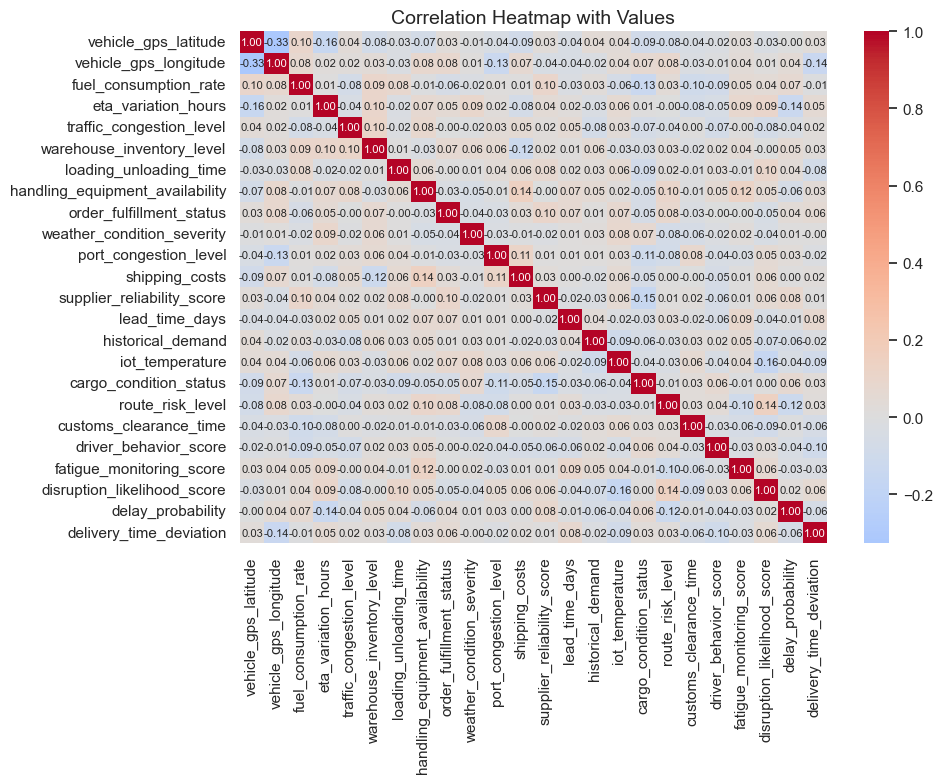

In [62]:

plt.figure(figsize=(10,8))
sns.heatmap(
    df[numeric_cols].corr(),
    cmap="coolwarm",
    center=0,
    annot=True,       # show numbers
    fmt=".2f",        # 2 decimal places
    annot_kws={"size":8}  # smaller font size if many variables
)
plt.title("Correlation Heatmap with Values", fontsize=14)
plt.tight_layout()
plt.show()


In [77]:
df["fatigue_monitoring_score"].describe()

count    300.000000
mean       0.599309
std        0.347843
min        0.000137
25%        0.256922
50%        0.709233
75%        0.923985
max        1.000000
Name: fatigue_monitoring_score, dtype: float64


=== eta_level ===


,eta_level,count,mean,median,std
0,Early (<0),47,0.811236,0.914338,0.214625
1,Large Delay (>4h),147,0.688033,0.860668,0.348339
2,Moderate Delay (2–4h),55,0.706076,0.818131,0.305656
3,Small Delay (0–2h),51,0.708735,0.896876,0.334826


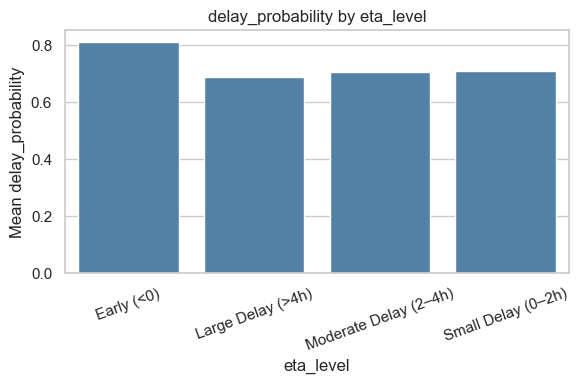


=== route_risk_level_cat ===


,route_risk_level_cat,count,mean,median,std
0,High Risk (7–10),178,0.689649,0.839800,0.331400
1,Low Risk (0–3),50,0.820856,0.930071,0.245636
2,Medium Risk (3–7),72,0.700671,0.840447,0.334588


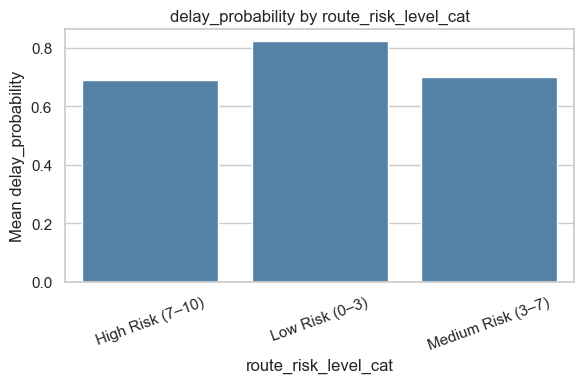


=== supplier_reliability_cat ===


,supplier_reliability_cat,count,mean,median,std
0,High Reliability,105,0.753758,0.904676,0.288851
1,Low Reliability,127,0.683627,0.837817,0.349048
2,Medium Reliability,68,0.710049,0.870913,0.316718


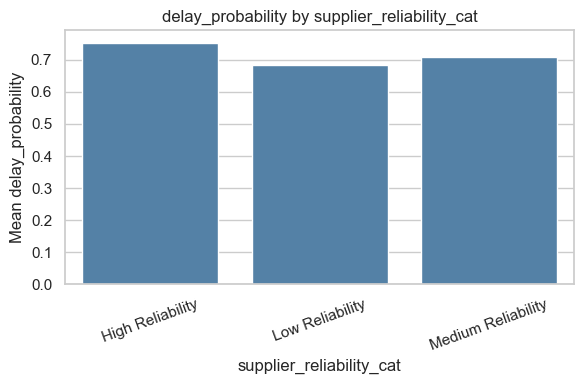

In [78]:
target = "delay_probability"

# --- Define categories based on your stats ---
def categorize_eta(x):
    if x < 0: 
        return "Early (<0)"
    elif x <= 2: 
        return "Small Delay (0–2h)"
    elif x <= 4: 
        return "Moderate Delay (2–4h)"
    else: 
        return "Large Delay (>4h)"

def categorize_route(x):
    if x <= 3:
        return "Low Risk (0–3)"
    elif x <= 7:
        return "Medium Risk (3–7)"
    else:
        return "High Risk (7–10)"

def categorize_supplier(x):
    if x <= 0.33:
        return "Low Reliability"
    elif x <= 0.66:
        return "Medium Reliability"
    else:
        return "High Reliability"

# --- Add new categorical columns ---
df_seg = df.copy()
df_seg["eta_level"] = df_seg["eta_variation_hours"].apply(categorize_eta)
df_seg["route_risk_level_cat"] = df_seg["route_risk_level"].apply(categorize_route)
df_seg["supplier_reliability_cat"] = df_seg["supplier_reliability_score"].apply(categorize_supplier)

# --- Function to summarize and plot ---
def level_summary(df, by, target=target):
    seg = df.groupby(by, observed=True)[target].agg(
        count="count", mean="mean", median="median", std="std"
    ).reset_index()

    print(f"\n=== {by} ===")
    display(seg)

    plt.figure(figsize=(6,4))
    sns.barplot(x=by, y="mean", data=seg, color="steelblue")  # use "mean"
    plt.ylabel(f"Mean {target}")
    plt.title(f"{target} by {by}")
    plt.xticks(rotation=20)
    plt.tight_layout()
    plt.show()

# --- Run summaries ---
for col in ["eta_level", "route_risk_level_cat", "supplier_reliability_cat"]:
    if col in df_seg.columns:
        level_summary(df_seg, col, target)



=== traffic_cat ===


,traffic_cat,count,mean,median,std
0,High Traffic,102,0.705827,0.850443,0.330994
1,Low Traffic,125,0.735560,0.896876,0.319537
2,Medium Traffic,73,0.689169,0.769091,0.316167


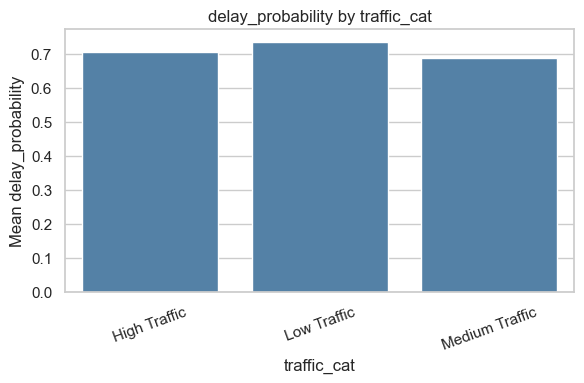


=== weather_cat ===


,weather_cat,count,mean,median,std
0,Mild,109,0.715157,0.841026,0.307688
1,Moderate,75,0.688760,0.836935,0.338185
2,Severe,116,0.729651,0.906092,0.326631


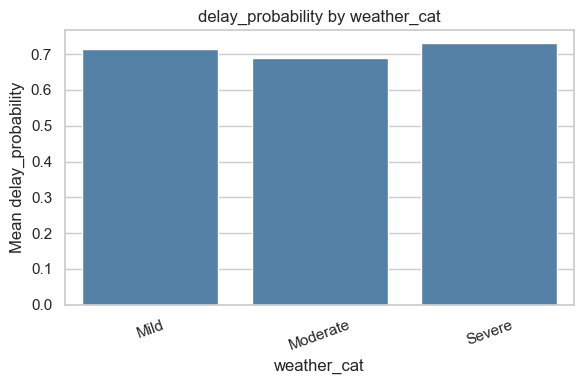


=== port_cat ===


,port_cat,count,mean,median,std
0,High Port Congestion,188,0.733370,0.876821,0.308803
1,Low Port Congestion,52,0.699765,0.880643,0.335178
2,Medium Port Congestion,60,0.666454,0.814952,0.350663


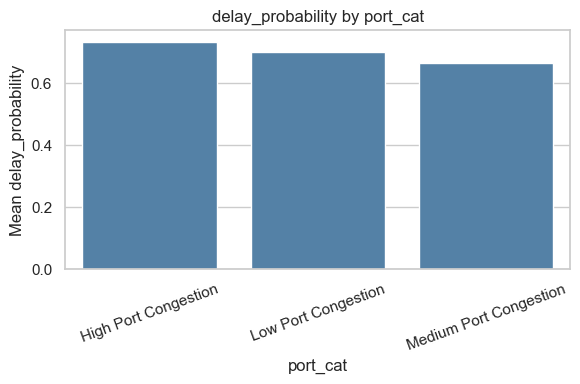


=== fatigue_cat ===


,fatigue_cat,count,mean,median,std
0,High Fatigue,160,0.713480,0.863314,0.327488
1,Low Fatigue,87,0.731534,0.843077,0.301383
2,Medium Fatigue,53,0.687705,0.868537,0.342668


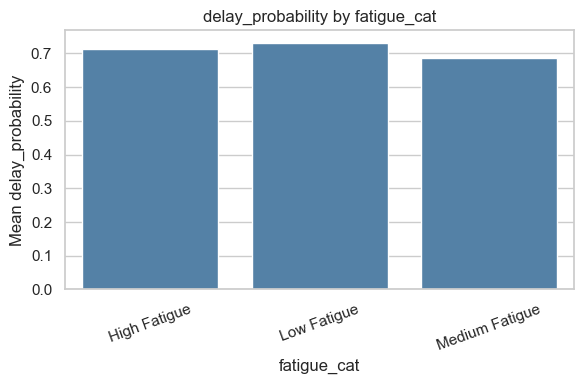

In [80]:
# --- Categorization functions ---
def bucket_traffic(x):
    if x <= 3: return "Low Traffic"
    elif x <= 7: return "Medium Traffic"
    else: return "High Traffic"

def bucket_weather(x):
    if x <= 0.33: return "Mild"
    elif x <= 0.66: return "Moderate"
    else: return "Severe"

def bucket_port(x):
    if x <= 3: return "Low Port Congestion"
    elif x <= 7: return "Medium Port Congestion"
    else: return "High Port Congestion"

def bucket_fatigue(x):
    if x <= 0.33: return "Low Fatigue"
    elif x <= 0.66: return "Medium Fatigue"
    else: return "High Fatigue"

# --- Apply categories ---
df_seg = df.copy()
df_seg["traffic_cat"] = df_seg["traffic_congestion_level"].apply(bucket_traffic)
df_seg["weather_cat"] = df_seg["weather_condition_severity"].apply(bucket_weather)
df_seg["port_cat"] = df_seg["port_congestion_level"].apply(bucket_port)
df_seg["fatigue_cat"] = df_seg["fatigue_monitoring_score"].apply(bucket_fatigue)

# --- Summary + plotting function ---
def level_summary(df, by, target=target):
    seg = df.groupby(by, observed=True)[target].agg(
        count="count", mean="mean", median="median", std="std"
    ).reset_index()

    print(f"\n=== {by} ===")
    display(seg)

    plt.figure(figsize=(6,4))
    sns.barplot(x=by, y="mean", data=seg, color="steelblue")  # use "mean"
    plt.ylabel(f"Mean {target}")
    plt.title(f"{target} by {by}")
    plt.xticks(rotation=20)
    plt.tight_layout()
    plt.show()

# --- Run summaries for these new categories ---
for col in ["traffic_cat", "weather_cat", "port_cat", "fatigue_cat"]:
    if col in df_seg.columns:
        level_summary(df_seg, col, target)


In [87]:
df["loading_unloading_time"].describe()

count    300.000000
mean       2.290302
std        1.598965
min        0.500000
25%        0.743004
50%        1.806209
75%        3.857619
max        4.998724
Name: loading_unloading_time, dtype: float64

In [85]:
targets = [
    "disruption_likelihood_score",
    "delivery_time_deviation",
    "delay_probability"
]

# Select numeric features only
num_df = df[numeric_cols].copy()

# Compute correlations
corrs = num_df.corr()[targets].drop(index=targets)  # drop self-corr rows

# For each target, sort by absolute correlation
for t in targets:
    print(f"\n=== Correlation with {t} ===")
    display(
        corrs[[t]]
        .assign(abs_corr=lambda x: x[t].abs())
        .sort_values("abs_corr", ascending=False)
        .drop(columns="abs_corr")
        .head(15)   # show top 15
    )




=== Correlation with disruption_likelihood_score ===


,disruption_likelihood_score
iot_temperature,-0.156120
route_risk_level,0.144896
loading_unloading_time,0.098653
eta_variation_hours,0.093257
customs_clearance_time,-0.091581
traffic_congestion_level,-0.077881
historical_demand,-0.073787
fatigue_monitoring_score,0.064921
supplier_reliability_score,0.058829
shipping_costs,0.057696



=== Correlation with delivery_time_deviation ===


,delivery_time_deviation
vehicle_gps_longitude,-0.143448
driver_behavior_score,-0.096171
iot_temperature,-0.086990
loading_unloading_time,-0.082442
lead_time_days,0.077003
customs_clearance_time,-0.056774
order_fulfillment_status,0.056155
eta_variation_hours,0.046935
handling_equipment_availability,0.031553
fatigue_monitoring_score,-0.029198



=== Correlation with delay_probability ===


,delay_probability
eta_variation_hours,-0.135586
route_risk_level,-0.123897
supplier_reliability_score,0.084820
fuel_consumption_rate,0.066678
cargo_condition_status,0.062596
handling_equipment_availability,-0.061695
historical_demand,-0.059350
warehouse_inventory_level,0.052440
vehicle_gps_longitude,0.044409
loading_unloading_time,0.040312


=== Handling Equipment Availability vs Delay Probability ===


,handling_equipment_availability,count,mean,median,std
0,0,212,0.726946,0.877735,0.312679
1,1,88,0.683364,0.835282,0.343847


/var/folders/5c/1lq7n0zj5kl_9m0ltvlt_7100000gn/T/ipykernel_64046/3573926151.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=by, y=target, data=df, estimator="mean", errorbar="sd", palette="Blues")


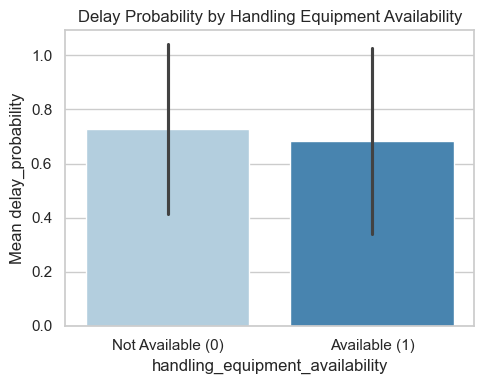

In [ ]:
target = "delay_probability"
by = "handling_equipment_availability"

# Group summary
seg = df.groupby(by, observed=True)[target].agg(
    count="count", mean="mean", median="median", std="std"
).reset_index()

print("=== Handling Equipment Availability vs Delay Probability ===")
display(seg)

# Plot
plt.figure(figsize=(5,4))
sns.barplot(x=by, y=target, data=df, estimator="mean", errorbar="sd", palette="Blues")
plt.ylabel(f"Mean {target}")
plt.title("Delay Probability by Handling Equipment Availability")
plt.xticks([0,1], ["Not Available (0)", "Available (1)"])
plt.tight_layout()
plt.show()



=== traffic_cat ===


,traffic_cat,count,mean,median,std
0,High Traffic,102,0.766735,0.936682,0.292431
1,Low Traffic,125,0.816547,0.961150,0.271528
2,Medium Traffic,73,0.789238,0.930428,0.275058


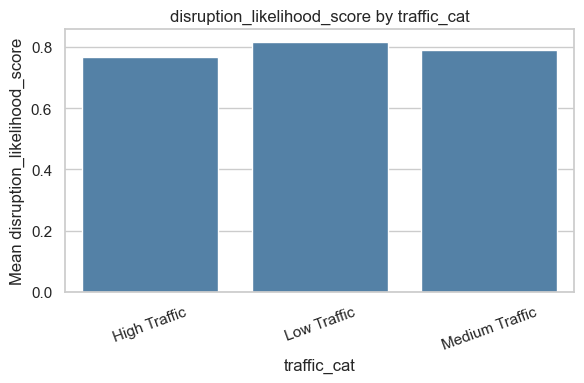


=== weather_cat ===


,weather_cat,count,mean,median,std
0,Mild,109,0.807264,0.962766,0.279380
1,Moderate,75,0.797483,0.963897,0.287514
2,Severe,116,0.776610,0.927449,0.276084


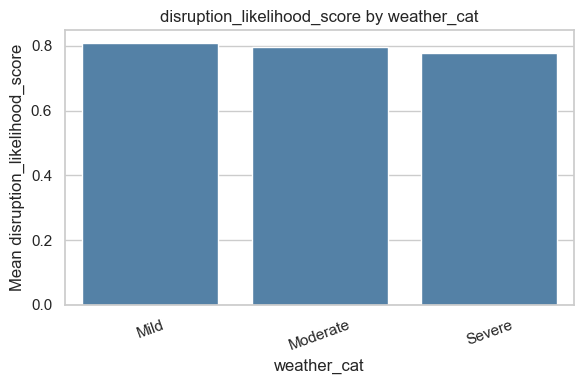


=== port_cat ===


,port_cat,count,mean,median,std
0,High Port Congestion,188,0.804426,0.962630,0.276650
1,Low Port Congestion,52,0.752845,0.869374,0.268235
2,Medium Port Congestion,60,0.791828,0.954881,0.299075


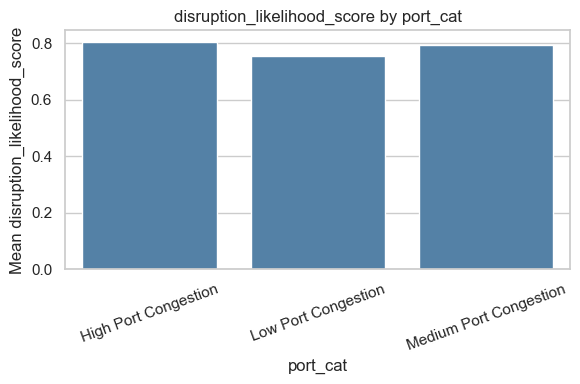


=== fatigue_cat ===


,fatigue_cat,count,mean,median,std
0,High Fatigue,160,0.808123,0.960396,0.269685
1,Low Fatigue,87,0.758112,0.930428,0.298173
2,Medium Fatigue,53,0.804419,0.938897,0.277623


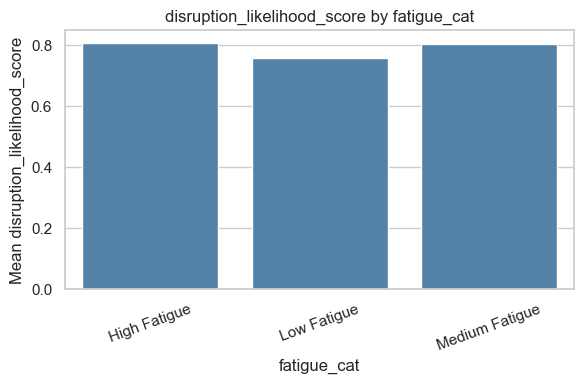


=== temp_cat ===


,temp_cat,count,mean,median,std
0,Cold (≤0°C),210,0.802260,0.961958,0.272225
1,Hot (>20°C),42,0.691655,0.810928,0.322510
2,Mild (0–20°C),48,0.840951,0.959349,0.254941


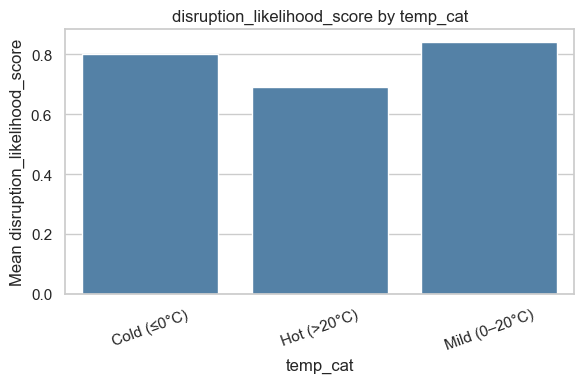


=== loading_cat ===


,loading_cat,count,mean,median,std
0,Fast (≤1.5h),135,0.745200,0.871090,0.295198
1,Normal (1.5–3h),57,0.832325,0.965300,0.247085
2,Slow (>3h),108,0.831900,0.972765,0.268458


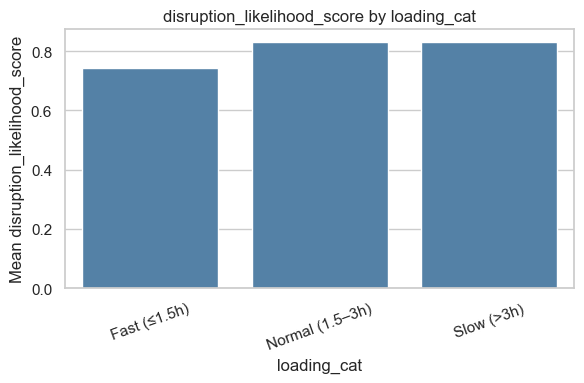


=== route_cat ===


,route_cat,count,mean,median,std
0,High Risk (7–10),178,0.825379,0.962825,0.255057
1,Low Risk (0–3),50,0.748962,0.920428,0.319004
2,Medium Risk (3–7),72,0.743390,0.905666,0.300365


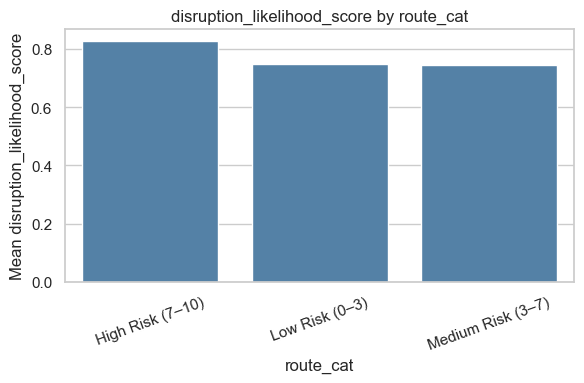


=== eta_cat ===


,eta_cat,count,mean,median,std
0,Early (<0h),47,0.760358,0.848989,0.268414
1,Large Delay (>4h),147,0.826495,0.963068,0.258075
2,Moderate Delay (2–4h),55,0.754992,0.938990,0.314604
3,Small Delay (0–2h),51,0.767326,0.923086,0.305171


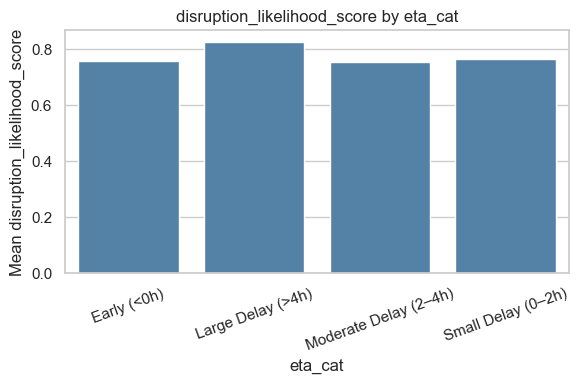


=== customs_cat ===


,customs_cat,count,mean,median,std
0,Fast (≤2h),150,0.804532,0.953603,0.273581
1,Moderate (2–6h),150,0.781399,0.943706,0.285853


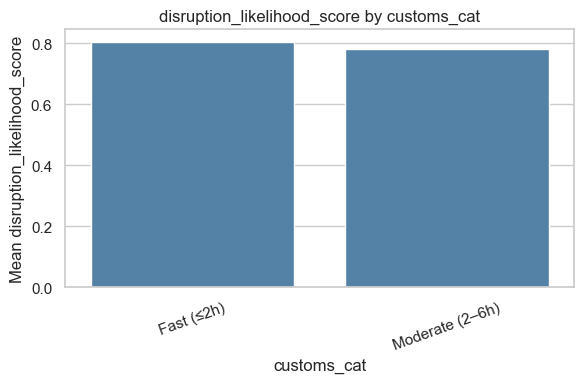

In [88]:
target = "disruption_likelihood_score"

# --- Categorization functions ---
def bucket_traffic(x):
    if x <= 3: return "Low Traffic"
    elif x <= 7: return "Medium Traffic"
    else: return "High Traffic"

def bucket_weather(x):
    if x <= 0.33: return "Mild"
    elif x <= 0.66: return "Moderate"
    else: return "Severe"

def bucket_port(x):
    if x <= 3: return "Low Port Congestion"
    elif x <= 7: return "Medium Port Congestion"
    else: return "High Port Congestion"

def bucket_fatigue(x):
    if x <= 0.33: return "Low Fatigue"
    elif x <= 0.66: return "Medium Fatigue"
    else: return "High Fatigue"

def bucket_temp(x):
    if x <= 0: return "Cold (≤0°C)"
    elif x <= 20: return "Mild (0–20°C)"
    else: return "Hot (>20°C)"

def bucket_loading(x):
    if x <= 1.5: return "Fast (≤1.5h)"
    elif x <= 3: return "Normal (1.5–3h)"
    else: return "Slow (>3h)"

def bucket_route(x):
    if x <= 3: return "Low Risk (0–3)"
    elif x <= 7: return "Medium Risk (3–7)"
    else: return "High Risk (7–10)"

def bucket_eta(x):
    if x < 0: return "Early (<0h)"
    elif x <= 2: return "Small Delay (0–2h)"
    elif x <= 4: return "Moderate Delay (2–4h)"
    else: return "Large Delay (>4h)"

def bucket_customs(x):
    if x <= 2: return "Fast (≤2h)"
    elif x <= 6: return "Moderate (2–6h)"
    else: return "Slow (>6h)"

# --- Apply categories ---
df_seg = df.copy()
df_seg["traffic_cat"] = df_seg["traffic_congestion_level"].apply(bucket_traffic)
df_seg["weather_cat"] = df_seg["weather_condition_severity"].apply(bucket_weather)
df_seg["port_cat"] = df_seg["port_congestion_level"].apply(bucket_port)
df_seg["fatigue_cat"] = df_seg["fatigue_monitoring_score"].apply(bucket_fatigue)
df_seg["temp_cat"] = df_seg["iot_temperature"].apply(bucket_temp)
df_seg["loading_cat"] = df_seg["loading_unloading_time"].apply(bucket_loading)
df_seg["route_cat"] = df_seg["route_risk_level"].apply(bucket_route)
df_seg["eta_cat"] = df_seg["eta_variation_hours"].apply(bucket_eta)
df_seg["customs_cat"] = df_seg["customs_clearance_time"].apply(bucket_customs)

# --- Summary + plotting function ---
def level_summary(df, by, target=target):
    seg = df.groupby(by, observed=True)[target].agg(
        count="count", mean="mean", median="median", std="std"
    ).reset_index()

    print(f"\n=== {by} ===")
    display(seg)

    plt.figure(figsize=(6,4))
    sns.barplot(x=by, y="mean", data=seg, color="steelblue")
    plt.ylabel(f"Mean {target}")
    plt.title(f"{target} by {by}")
    plt.xticks(rotation=20)
    plt.tight_layout()
    plt.show()

# --- Run summaries for all categories ---
for col in [
    "traffic_cat", "weather_cat", "port_cat", "fatigue_cat",
    "temp_cat", "loading_cat", "route_cat", "eta_cat", "customs_cat"
]:
    if col in df_seg.columns:
        level_summary(df_seg, col, target)

In [90]:

import folium
import branca.colormap as cm
lat_col = "vehicle_gps_latitude"
lon_col = "vehicle_gps_longitude"
value_col = "delay_probability"
geo = df[[lat_col, lon_col, value_col]].dropna()
geo = geo[geo[lat_col].between(-90, 90) & geo[lon_col].between(-180, 180)]

# Center & color scale
center = [geo[lat_col].mean(), geo[lon_col].mean()]
vmin, vmax = float(geo[value_col].min()), float(geo[value_col].max())
cmap = cm.linear.PuRd_09.scale(vmin, vmax)
cmap.caption = value_col.replace("_", " ").title()

# Size scaling
def scale_radius(x, min_r=4, max_r=16):
    if np.isnan(x) or vmax == vmin:
        return (min_r + max_r) / 2
    return min_r + (max_r - min_r) * (x - vmin) / (vmax - vmin)

# Build map
m = folium.Map(location=center, zoom_start=10, tiles="cartodbpositron")

for _, r in geo.iterrows():
    val = float(r[value_col])
    folium.CircleMarker(
        location=[r[lat_col], r[lon_col]],
        radius=scale_radius(val),
        color=None,
        fill=True,
        fill_color=cmap(val),
        fill_opacity=0.7,
        tooltip=f"{value_col}: {val:.3f}",
    ).add_to(m)

cmap.add_to(m)         # legend
# No saving; just show inline by returning `m` as the last expression:
m


In [ ]:
base_predictors = [
    "traffic_congestion_level",
    "port_congestion_level",
    "weather_condition_severity",
    "customs_clearance_time",   # make sure all in hours
    "loading_unloading_time",
    "handling_equipment_availability",
    "warehouse_inventory_level",
    "supplier_reliability_score",
    "lead_time_days",
    "driver_behavior_score",
    "fatigue_monitoring_score",
    "iot_temperature",
    "route_risk_level",
]


In [104]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = pd.DataFrame(
    scaler.fit_transform(X_full),
    columns=X_full.columns,
    index=X_full.index
)

Selected features per method:
  AIC_Forward: ['iot_temperature', 'route_risk_level', 'loading_unloading_time', 'fatigue_monitoring_score', 'customs_clearance_time']
  AIC_Backward: ['customs_clearance_time', 'loading_unloading_time', 'fatigue_monitoring_score', 'iot_temperature', 'route_risk_level']
  P_Forward: ['iot_temperature', 'route_risk_level']
  P_Backward: ['iot_temperature', 'route_risk_level']

MAE summary (mean/median/std):
                mean  median     std
AIC_Forward   0.2194  0.2219  0.0183
AIC_Backward  0.2194  0.2219  0.0183
P_Forward     0.2234  0.2241  0.0185
P_Backward    0.2234  0.2241  0.0185


/var/folders/5c/1lq7n0zj5kl_9m0ltvlt_7100000gn/T/ipykernel_64046/3153740895.py:157: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


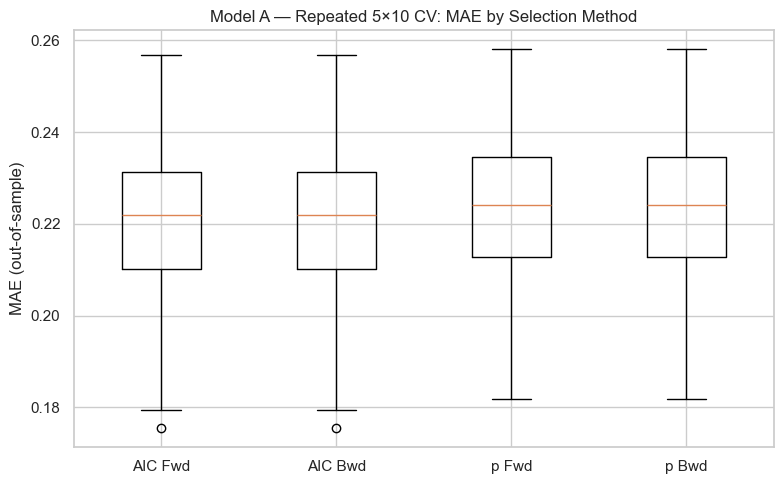

In [ ]:
# p-value thresholds
P_IN = 0.05
P_OUT = 0.05
TARGET = "disruption_likelihood_score"
# -----------------------------
# Load data
# -----------------------------
data = df[[TARGET] + base_predictors].replace([np.inf, -np.inf], np.nan).dropna().copy()
data[TARGET] = data[TARGET].clip(0, 1)

X_full = data[base_predictors].copy()
y = data[TARGET].values

# -----------------------------
# Helpers
# -----------------------------
def fit_sm_ols(X_df, y_vec):
    """Fit OLS with intercept using statsmodels."""
    X1 = sm.add_constant(X_df, has_constant='add')
    return sm.OLS(y_vec, X1).fit()

def stepwise_aic_forward(X_df, y_vec, verbose=False):
    remaining = list(X_df.columns)
    selected = []
    # Intercept-only AIC
    current_aic = fit_sm_ols(pd.DataFrame(index=X_df.index), y_vec).aic
    improved = True
    while improved and remaining:
        cand_scores = []
        for c in remaining:
            model = fit_sm_ols(pd.DataFrame(X_df[selected + [c]]), y_vec)
            cand_scores.append((model.aic, c))
        cand_scores.sort(key=lambda x: x[0])
        best_aic, best_cand = cand_scores[0]
        if best_aic < current_aic - 1e-6:
            selected.append(best_cand)
            remaining.remove(best_cand)
            current_aic = best_aic
            if verbose:
                print(f"[AIC Fwd] +{best_cand} -> AIC {current_aic:.3f}")
        else:
            improved = False
    return selected

def stepwise_aic_backward(X_df, y_vec, verbose=False):
    selected = list(X_df.columns)
    if not selected:
        return []
    current_aic = fit_sm_ols(X_df[selected], y_vec).aic
    improved = True
    while improved and selected:
        trials = []
        for c in list(selected):
            keep = [f for f in selected if f != c]
            model = fit_sm_ols(X_df[keep], y_vec) if keep else fit_sm_ols(pd.DataFrame(index=X_df.index), y_vec)
            trials.append((model.aic, c, keep))
        trials.sort(key=lambda x: x[0])
        best_aic, removed, best_set = trials[0]
        if best_aic < current_aic - 1e-6:
            selected = best_set
            current_aic = best_aic
            if verbose:
                print(f"[AIC Bwd] -{removed} -> AIC {current_aic:.3f}")
        else:
            improved = False
    return selected

def stepwise_p_forward(X_df, y_vec, threshold_in=0.05, verbose=False):
    remaining = list(X_df.columns)
    selected = []
    while remaining:
        best_p, best_feat = None, None
        for c in remaining:
            model = fit_sm_ols(pd.DataFrame(X_df[selected + [c]]), y_vec)
            pvals = model.pvalues.drop('const', errors='ignore')
            p_c = pvals.get(c, None)
            if p_c is not None and (best_p is None or p_c < best_p):
                best_p, best_feat = p_c, c
        if best_p is not None and best_p < threshold_in:
            selected.append(best_feat)
            remaining.remove(best_feat)
            if verbose:
                print(f"[p Fwd] +{best_feat} (p={best_p:.4f})")
        else:
            break
    return selected

def stepwise_p_backward(X_df, y_vec, threshold_out=0.05, verbose=False):
    selected = list(X_df.columns)
    while selected:
        model = fit_sm_ols(X_df[selected], y_vec)
        pvals = model.pvalues.drop('const', errors='ignore')
        if pvals.empty:
            break
        worst_p = pvals.max()
        worst_feat = pvals.idxmax()
        if worst_p > threshold_out:
            selected.remove(worst_feat)
            if verbose:
                print(f"[p Bwd] -{worst_feat} (p={worst_p:.4f})")
        else:
            break
    return selected

def cv_maes_for_feature_set(X_df, y_vec, feats, n_splits=5, n_repeats=10, seed=42):
    """Repeated K-fold CV MAEs for a given feature set using sklearn LinearRegression."""
    rkf = RepeatedKFold(n_splits=n_splits, n_repeats=n_repeats, random_state=seed)
    maes = []
    if len(feats) == 0:
        # Intercept-only baseline via mean in train fold
        for tr, te in rkf.split(X_df):
            y_tr, y_te = y_vec[tr], y_vec[te]
            y_pred = np.repeat(np.mean(y_tr), len(te))
            maes.append(mean_absolute_error(y_te, y_pred))
        return maes
    X_sub = X_df[feats].values
    lr = LinearRegression()
    for tr, te in rkf.split(X_sub):
        lr.fit(X_sub[tr], y_vec[tr])
        pred = lr.predict(X_sub[te]).clip(0, 1)  # keep in [0,1]
        maes.append(mean_absolute_error(y_vec[te], pred))
    return maes

# -----------------------------
# Run selections
# -----------------------------
sel_AIC_fwd  = stepwise_aic_forward(X_scaled, y)
sel_AIC_bwd  = stepwise_aic_backward(X_scaled, y)
sel_p_fwd    = stepwise_p_forward(X_scaled, y, threshold_in=P_IN)
sel_p_bwd    = stepwise_p_backward(X_scaled, y, threshold_out=P_OUT)

selected_sets = {
    "AIC_Forward": sel_AIC_fwd,
    "AIC_Backward": sel_AIC_bwd,
    "P_Forward": sel_p_fwd,
    "P_Backward": sel_p_bwd
}

print("Selected features per method:")
for name, feats in selected_sets.items():
    print(f"  {name}: {feats if feats else 'Intercept only'}")

# -----------------------------
# Repeated K-fold CV (50 MAEs per method)
# -----------------------------
mae_results = {name: cv_maes_for_feature_set(X_scaled, y, feats)
               for name, feats in selected_sets.items()}

mae_df = pd.DataFrame({k: pd.Series(v) for k, v in mae_results.items()})
print("\nMAE summary (mean/median/std):")
print(mae_df.agg(['mean', 'median', 'std']).T.round(4))

# -----------------------------
# Boxplot
# -----------------------------
plt.figure(figsize=(8, 5))
plt.boxplot(
    [mae_results["AIC_Forward"],
     mae_results["AIC_Backward"],
     mae_results["P_Forward"],
     mae_results["P_Backward"]],
    labels=["AIC Fwd", "AIC Bwd", "p Fwd", "p Bwd"]
)
plt.ylabel("MAE (out-of-sample)")
plt.title("Disruption Likelihood Score — Repeated 5×10 CV: MAE by Selection Method")
plt.tight_layout()
plt.show()

# (Optional) save table
# mae_df.to_csv("modelA_mae_repeated_cv.csv", index=False)


In [142]:
model_aic_fwd_disruption = fit_sm_ols(X_scaled[sel_AIC_fwd], y)
print("\n=== AIC-Forward Stepwise OLS Summary for Disruption Likelihood Score ===")
print(model_aic_fwd_disruption.summary())



=== AIC-Forward Stepwise OLS Summary for Disruption Likelihood Score ===
                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.039
Model:                            OLS   Adj. R-squared:                  0.026
Method:                 Least Squares   F-statistic:                     3.026
Date:                Thu, 02 Oct 2025   Prob (F-statistic):             0.0181
Time:                        00:49:23   Log-Likelihood:                -132.15
No. Observations:                 300   AIC:                             274.3
Df Residuals:                     295   BIC:                             292.8
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                                 coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------

Selected features per method:
  AIC_Forward: ['supplier_reliability_score', 'loading_unloading_time', 'lead_time_days', 'driver_behavior_score']
  AIC_Backward: ['loading_unloading_time', 'supplier_reliability_score', 'lead_time_days', 'driver_behavior_score']
  P_Forward: ['supplier_reliability_score']
  P_Backward: ['supplier_reliability_score']

MAE summary (mean/median/std):
                mean  median     std
AIC_Forward   0.2983  0.2976  0.0230
AIC_Backward  0.2983  0.2976  0.0230
P_Forward     0.3027  0.3009  0.0208
P_Backward    0.3027  0.3009  0.0208


/var/folders/5c/1lq7n0zj5kl_9m0ltvlt_7100000gn/T/ipykernel_64046/1464024608.py:43: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


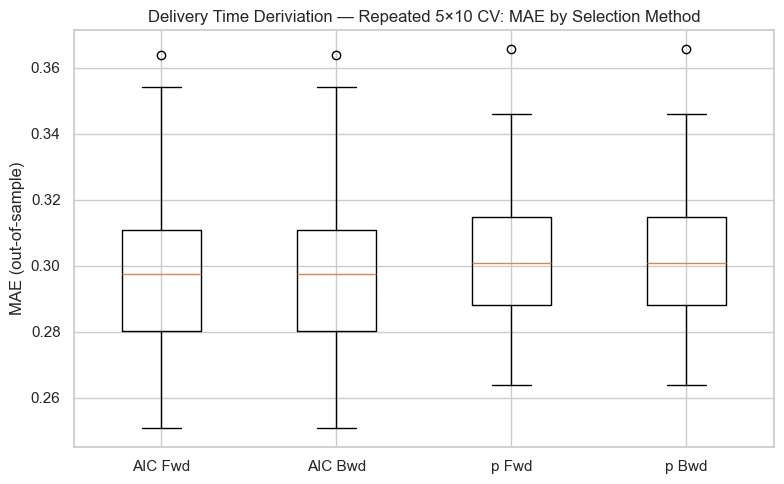

In [164]:
TARGET = "delivery_time_deviation"
# -----------------------------
# Load data
# -----------------------------
data = df[[TARGET] + base_predictors].replace([np.inf, -np.inf], np.nan).dropna().copy()
data[TARGET] = data[TARGET].clip(0, 1)

X_full = data[base_predictors].copy()
y = data[TARGET].values
# -----------------------------
# Run selections
# -----------------------------
sel_AIC_fwd  = stepwise_aic_forward(X_scaled, y)
sel_AIC_bwd  = stepwise_aic_backward(X_scaled, y)
sel_p_fwd    = stepwise_p_forward(X_scaled, y, threshold_in=P_IN)
sel_p_bwd    = stepwise_p_backward(X_scaled, y, threshold_out=P_OUT)

selected_sets = {
    "AIC_Forward": sel_AIC_fwd,
    "AIC_Backward": sel_AIC_bwd,
    "P_Forward": sel_p_fwd,
    "P_Backward": sel_p_bwd
}

print("Selected features per method:")
for name, feats in selected_sets.items():
    print(f"  {name}: {feats if feats else 'Intercept only'}")

# -----------------------------
# Repeated K-fold CV (50 MAEs per method)
# -----------------------------
mae_results = {name: cv_maes_for_feature_set(X_scaled, y, feats)
               for name, feats in selected_sets.items()}

mae_df = pd.DataFrame({k: pd.Series(v) for k, v in mae_results.items()})
print("\nMAE summary (mean/median/std):")
print(mae_df.agg(['mean', 'median', 'std']).T.round(4))

# -----------------------------
# Boxplot
# -----------------------------
plt.figure(figsize=(8, 5))
plt.boxplot(
    [mae_results["AIC_Forward"],
     mae_results["AIC_Backward"],
     mae_results["P_Forward"],
     mae_results["P_Backward"]],
    labels=["AIC Fwd", "AIC Bwd", "p Fwd", "p Bwd"]
)
plt.ylabel("MAE (out-of-sample)")
plt.title("Delivery Time Deriviation — Repeated 5×10 CV: MAE by Selection Method")
plt.tight_layout()
plt.show()

# (Optional) save table
# mae_df.to_csv("modelA_mae_repeated_cv.csv", index=False)


In [ ]:
model_aic_fwd_delivery = fit_sm_ols(X_scaled[sel_AIC_fwd], y)
print("\n=== AIC-Forward Stepwise OLS Summary for Delivery Time Deviation ===")
print(model_aic_fwd_delivery.summary())


=== AIC-Forward Stepwise OLS Summary for Delivery Time Deviation ===
                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.023
Model:                            OLS   Adj. R-squared:                  0.016
Method:                 Least Squares   F-statistic:                     3.469
Date:                Thu, 02 Oct 2025   Prob (F-statistic):             0.0324
Time:                        01:34:02   Log-Likelihood:                -81.910
No. Observations:                 300   AIC:                             169.8
Df Residuals:                     297   BIC:                             180.9
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                                 coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------

Regression tree — MAE (vs prob): 0.2932
Regression tree — Brier (vs 0/1): 0.1958
Baseline constant-prob Brier (~0.76): 0.1833


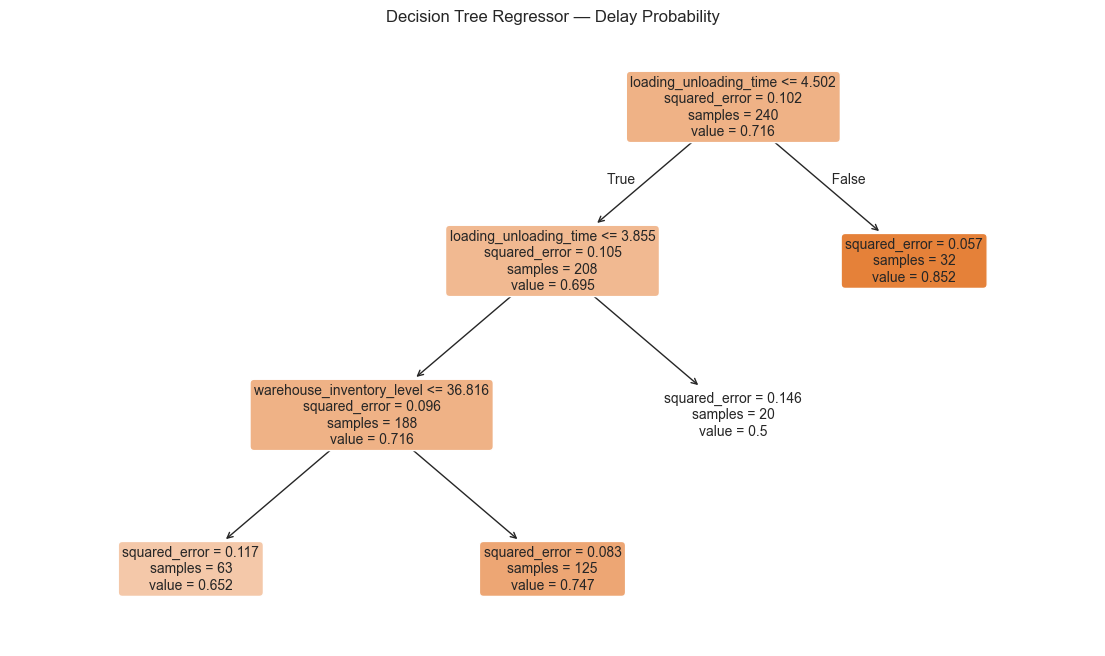


Plain-text rules:
|--- loading_unloading_time <= 4.50
|   |--- loading_unloading_time <= 3.86
|   |   |--- warehouse_inventory_level <= 36.82
|   |   |   |--- value: [0.65]
|   |   |--- warehouse_inventory_level >  36.82
|   |   |   |--- value: [0.75]
|   |--- loading_unloading_time >  3.86
|   |   |--- value: [0.50]
|--- loading_unloading_time >  4.50
|   |--- value: [0.85]

driver_behavior_bucket code→label: {0: 'Low', 1: 'Medium', 2: 'High'}
route_risk_bucket code→label: {0: 'Low', 1: 'Medium', 2: 'High'}
temp_bucket code→label: {0: 'Cool', 1: 'Normal', 2: 'Hot'}


In [158]:

# --- 1) Prepare X (bucketed + encoded) and y ---
Xbinned = df[base_predictors].copy()
y = df["delay_probability"].clip(0, 1)

# Buckets (for cleaner, business-friendly rules)
Xbinned["driver_behavior_bucket"] = pd.cut(
    Xbinned["driver_behavior_score"], bins=[-0.1, 0.3, 0.7, 1.0],
    labels=["Low", "Medium", "High"]
)
Xbinned["route_risk_bucket"] = pd.cut(
    Xbinned["route_risk_level"], bins=[-0.1, 3, 7, 10],
    labels=["Low", "Medium", "High"]
)
Xbinned["temp_bucket"] = pd.cut(
    Xbinned["iot_temperature"], bins=[-50, 20, 30, 100],
    labels=["Cool", "Normal", "Hot"]
)

# Drop NAs
mask = Xbinned.notna().all(axis=1) & y.notna()
X = Xbinned.loc[mask].copy()
y = y.loc[mask].copy()

# Binary label for Brier score (optional but useful)
y_bin = (y > 0.5).astype(int)

# Enforce desired category order (not alphabetical)
bucket_cols = ["driver_behavior_bucket", "route_risk_bucket", "temp_bucket"]
desired_orders = {
    "driver_behavior_bucket": ["Low", "Medium", "High"],
    "route_risk_bucket": ["Low", "Medium", "High"],
    "temp_bucket": ["Cool", "Normal", "Hot"],
}
for col in bucket_cols:
    X[col] = X[col].astype(pd.CategoricalDtype(categories=desired_orders[col], ordered=True))

# Ordinal-encode buckets with explicit order
encoder = OrdinalEncoder(categories=[desired_orders[c] for c in bucket_cols])
X_encoded = X.copy()
X_encoded[bucket_cols] = encoder.fit_transform(X[bucket_cols])

# Optional: light cleaning of obvious outliers for visuals
if "iot_temperature" in X_encoded.columns:
    X_encoded["iot_temperature"] = X_encoded["iot_temperature"].clip(lower=0, upper=50)

# --- 2) Split ---
X_tr, X_te, y_tr, y_te, ybin_tr, ybin_te = train_test_split(
    X_encoded, y, y_bin, test_size=0.2, random_state=42, stratify=y_bin
)

# --- 3) Regression tree (predicts probability directly) ---
reg = DecisionTreeRegressor(
    max_depth=3,
    min_samples_leaf=20,   # helps avoid tiny, unstable leaves
    random_state=42
)
reg.fit(X_tr, y_tr)

# Predict & evaluate
pred = np.clip(reg.predict(X_te), 0, 1)
mae = mean_absolute_error(y_te, pred)
brier = brier_score_loss(ybin_te, pred)  # compare to 0/1 label
print(f"Regression tree — MAE (vs prob): {mae:.4f}")
print(f"Regression tree — Brier (vs 0/1): {brier:.4f}")

# Baseline for context (best constant prob is prevalence of delay>0.5)
p = ybin_tr.mean()
baseline_brier = p * (1 - p)
print(f"Baseline constant-prob Brier (~{p:.2f}): {baseline_brier:.4f}")

# --- 4) Visualize the tree ---
plt.figure(figsize=(14, 8))
plot_tree(
    reg,
    feature_names=list(X_encoded.columns),
    filled=True,
    rounded=True,
    fontsize=10
)
plt.title("Decision Tree Regressor — Delay Probability")
plt.show()

# Optional: plain-text rules (numeric thresholds)
print("\nPlain-text rules:")
print(export_text(reg, feature_names=list(X_encoded.columns)))

# --- 5) Print mappings so you can read bucket splits nicely ---
for col, cats in zip(bucket_cols, encoder.categories_):
    print(f"{col} code→label:", {i: lab for i, lab in enumerate(cats)})


<Axes: >

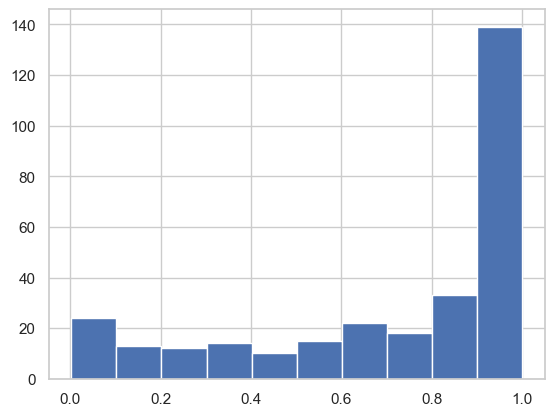

In [159]:
df["delay_probability"].hist()